<a href="https://colab.research.google.com/github/iv23995-ctrl/CI345_ML/blob/main/Lab8_KNN_MovieStore_finished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
#

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# lab 8 - knn classification for Video data



#Step 1: Loading & Analyzing Data

In [77]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [78]:
df = orginal_vtable.head(3)





In [79]:
vtable = df
vtable['Income'] = vtable['Income'].astype(float)
vtable.dtypes

/tmp/ipykernel_1162/4220580461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtable['Income'] = vtable['Income'].astype(float)


,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [80]:

print('------------------------')
#print(df['Income'].describe())


------------------------


In [81]:
df = orginal_vtable


#Step 2: Data Visulization

In [82]:
df = orginal_vtable


<Axes: title={'center': 'Percentage'}, ylabel='count'>

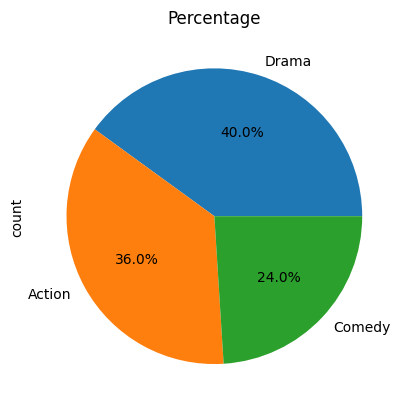

In [83]:
res = df['Genre'].value_counts()

res.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Percentage'
)

array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

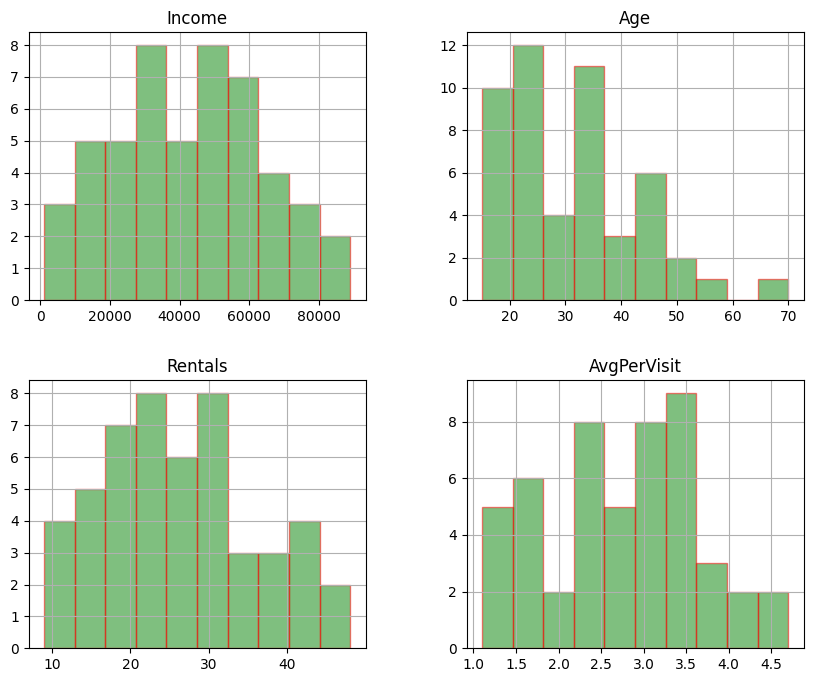

In [84]:
df = orginal_vtable
res = df[['Income','Age','Rentals','AvgPerVisit']]
res.hist(alpha=0.5, edgecolor='red', color='green', figsize=(10,8))

In [85]:
res = df['Like'].value_counts()


#Step 3: Method of Convert of Categorical Data


# Method 1 : Use Label Encoder

In [86]:
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No


In [87]:
# Need Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 1 : Using LabelEncoder
# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

print('--------')
df = orginal_vtable
from sklearn.preprocessing import LabelEncoder

# All category feature need to transfer to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
print(df.dtypes)
print(df.head(2))

# vs Method


print(df.dtypes)
df.head(2)

--------
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        0       1      19    8       20           10      0     1
1        1       0      24   13        2           18      2     0
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,0,1,19,8,20,10,0,1
1,1,0,24,13,2,18,2,0


#Step 4: KNN Classifications

In [100]:
# Current process data has not category
vtable = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,M,45000,25,32,2.5,Action
1,F,54000,33,12,3.4,Drama
2,F,32000,20,42,1.6,Comedy


In [89]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 6)
(10, 6)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.50      1.00      0.67         3

    accuracy                           0.70        10
   macro avg       0.75      0.79      0.70        10
weighted avg       0.85      0.70      0.71        10

------ Confusion Matrix
[[4 3]
 [0 3]]



# Converting categoric feature to numerical feature

## Method 2 : Using get_dummies -

In [90]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies
df = orginal_vtable
print(df.head(2))
gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


   Cust ID Gender  Income  Age  Rentals  AvgPerVisit   Genre Like
0        1      M   45000   25       32          2.5  Action  Yes
1        2      F   54000   33       12          3.4   Drama   No
Cust ID           int64
Income            int64
Age               int64
Rentals           int64
AvgPerVisit     float64
Gender_F           bool
Gender_M           bool
Genre_Action       bool
Genre_Comedy       bool
Genre_Drama        bool
Like_No            bool
Like_Yes           bool
dtype: object
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25       32          2.5     False      True   
1        2   54000   33       12          3.4      True     False   

   Genre_Action  Genre_Comedy  Genre_Drama  Like_No  Like_Yes  
0          True         False        False    False      True  
1         False         False         True     True     False  
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25       3

In [91]:
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies -
df = orginal_vtable

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Apply get_dummies to categorical columns, dropping the first to avoid multicollinearity
df_dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

# Combine with numerical columns
df_use_dummies = pd.concat([df[numeric_cols], df_dummies], axis=1)

print(df_use_dummies.shape)
df_use_dummies.head(2)

(50, 9)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_M,Genre_Comedy,Genre_Drama,Like_Yes
0,1,45000,25,32,2.5,True,False,False,True
1,2,54000,33,12,3.4,False,False,True,False


In [102]:
# Current process data has not category
vtable = df_use_dummies
# Seperate data part
v_data = vtable[['Cust ID','Income','Age','Rentals', 'AvgPerVisit','Gender_M','Genre_Comedy','Genre_Drama']]
v_target = vtable['Like_Yes']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 8)
(50,)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_M,Genre_Comedy,Genre_Drama
0,1,45000,25,32,2.5,True,False,False
1,2,54000,33,12,3.4,False,False,True
2,3,32000,20,42,1.6,False,True,False


In [92]:
# Separate data and target, after use dummies

# Get all columns from df_use_dummies
all_cols = df_use_dummies.columns.tolist()

# Identify target column (Likely 'Like_Yes' based on df_use_dummies.head(2) output)
target_col = 'Like_Yes'

# Separate data part (features)
v_data = df_use_dummies.drop(columns=[target_col])

# Get target
v_target = df_use_dummies[target_col]


print(v_data.shape)
print(v_target.shape)

(50, 8)
(50,)


In [93]:
v_data.head(2)

,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_M,Genre_Comedy,Genre_Drama
0,1,45000,25,32,2.5,True,False,False
1,2,54000,33,12,3.4,False,False,True


In [94]:
v_target.head(2)

,Like_Yes
0,True
1,False


In [95]:
data_train.describe()

,Gender,Income,Age,Rentals,AvgPerVisit,Genre
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.525000,17.600000,11.275000,14.775000,12.775000,1.025000
std,0.505736,9.572396,6.405076,8.300409,6.844378,0.919518
min,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000
25%,0.000000,9.750000,6.750000,8.000000,7.000000,0.000000
50%,1.000000,18.500000,11.000000,14.500000,13.500000,1.000000
75%,1.000000,25.000000,14.250000,20.250000,17.250000,2.000000
max,1.000000,34.000000,24.000000,30.000000,26.000000,2.000000


In [96]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

       False       1.00      0.29      0.44         7
        True       0.38      1.00      0.55         3

    accuracy                           0.50        10
   macro avg       0.69      0.64      0.49        10
weighted avg       0.81      0.50      0.47        10

------ Confusion Matrix
[[2 5]
 [0 3]]


#Step 3: Data Procecessing

###Convert categoric feature to numerical feature

#Method 3 : Using HotOneEncoder


In [97]:
#use scores method
score = knn_classifier.score(data_test, target_test)
score

0.5

In [98]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

[[2 5]
 [0 3]]


In [99]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.29      0.44         7
        True       0.38      1.00      0.55         3

    accuracy                           0.50        10
   macro avg       0.69      0.64      0.49        10
weighted avg       0.81      0.50      0.47        10

